## Hate Speech Classification



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Data

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv(r"/content/drive/MyDrive/NLP_Project/imbalanced_data.csv")

In [ ]:
df

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation
...,...,...,...
31957,31958,0,ate @user isz that youuu?ðððððð...
31958,31959,0,to see nina turner on the airwaves trying to...
31959,31960,0,listening to sad songs on a monday morning otw...
31960,31961,1,"@user #sikh #temple vandalised in in #calgary,..."


In [ ]:
df.drop(columns="id",inplace=True)

In [ ]:
df

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation
...,...,...
31957,0,ate @user isz that youuu?ðððððð...
31958,0,to see nina turner on the airwaves trying to...
31959,0,listening to sad songs on a monday morning otw...
31960,1,"@user #sikh #temple vandalised in in #calgary,..."


In [ ]:
print(df.isnull().sum())

label    0
tweet    0
dtype: int64


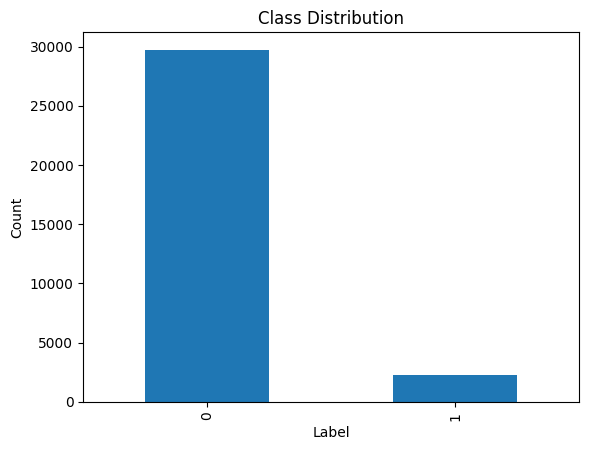

In [ ]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

## Text Cleaning

In [ ]:
from nltk.corpus import stopwords
import re
import string
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
stemmer = nltk.SnowballStemmer("english")
stopword = set(stopwords.words('english'))

In [ ]:
def data_cleaning(words):
    words = str(words).lower()
    words = re.sub('\[.*?\]', '', words)
    words = re.sub('https?://\S+|www\.\S+', '', words)
    words = re.sub('<.*?>+', '', words)
    words = re.sub('[%s]' % re.escape(string.punctuation), '', words)
    words = re.sub('\n', '', words)
    words = re.sub('@', '', words)
    words = re.sub('ur.+', '', words)
    words = re.sub('ð.+', '', words)
    words = re.sub('\s[\s+]', '', words)
    words = re.sub('\w*\d\w*', '', words)
    words = re.sub('â.+', '', words)


    words = [word for word in words.split(' ') if words not in stopword]
    words=" ".join(words)
    words = [stemmer.stem(words) for word in words.split(' ')]
    words=" ".join(words)

    return words

<>:3: SyntaxWarning: invalid escape sequence '\['
<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\['
<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_21426/758862004.py:3: SyntaxWarning: invalid escape sequence '\['
  words = re.sub('\[.*?\]', '', words)
/tmp/ipykernel_21426/758862004.py:4: SyntaxWarning: invalid escape sequence '\S'
  words = re.sub('https?://\S+|www\.\S+', '', words)
/tmp/ipykernel_21426/758862004.py:11: SyntaxWarning: invalid escape sequence '\s'
  words = re.sub('\s[\s+]', '', words)
/tmp/ipykernel_21426/758862004.py:12: SyntaxWarning: invalid escape sequence '\w'
  words = re.sub('\w*\d\w*', '', words)


In [ ]:
df['tweet']=df['tweet'].apply(data_cleaning)

In [ ]:
df

,label,tweet
0,0,user when a father is dysfunctional and is so...
1,0,user user thanks for lyft credit i cant use ca...
2,0,bihday yo bihday yo
3,0,model i love u take with u all the time in mo...
4,0,factsguide society nowmotiv factsguide socie...
...,...,...
31957,0,ate user isz that youuu ate user isz that youu...
31958,0,to see nina t to see nina t to see nina t to s...
31959,0,listening to sad songs on a monday morning otw...
31960,1,user sikh temple vandalised in in calgary wso ...


In [ ]:
df["tweet"][1]

'user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdxdisapointed getthank user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdxdisapointed getthank user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdxdisapointed getthank user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdxdisapointed getthank user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdxdisapointed getthank user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdxdisapointed getthank user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdxdisapointed getthank user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdxdisapointed getthank user user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdxdisapointed getthank user user thanks f

## Removing repeated sentance

In [ ]:
def remove_duplicate_words(text):
    words = text.split()

    seen = set()
    result = []

    for word in words:
        if word not in seen:
            result.append(word)
            seen.add(word)

    return " ".join(result)

df['tweet'] = df['tweet'].apply(remove_duplicate_words)

In [ ]:
df["tweet"][1]

'user thanks for lyft credit i cant use cause they dont offer wheelchair vans in pdxdisapointed getthank'

### Understanding the data

In [ ]:
df['text_length'] = df['tweet'].apply(lambda x: len(x.split()))

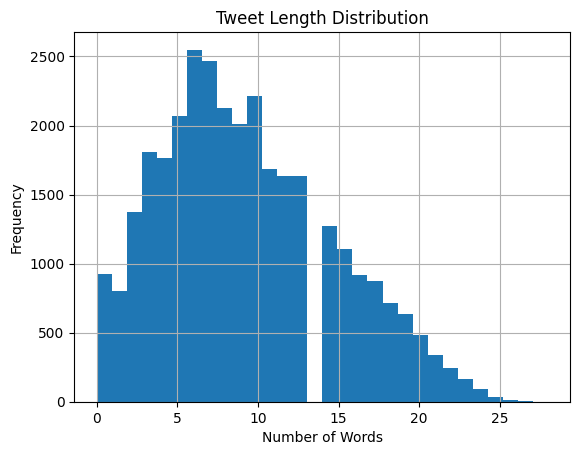

In [ ]:
df['text_length'].hist(bins=30)
plt.title("Tweet Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from collections import Counter

all_words = " ".join(df['tweet']).split()
word_counts = Counter(all_words)

print(word_counts.most_common(20))

[('user', 9677), ('the', 7085), ('to', 6743), ('a', 4716), ('i', 4633), ('for', 3656), ('you', 3540), ('in', 3523), ('and', 3463), ('is', 3207), ('of', 3201), ('my', 3000), ('this', 2195), ('with', 2045), ('on', 2000), ('be', 1900), ('yo', 1826), ('all', 1681), ('love', 1666), ('it', 1666)]


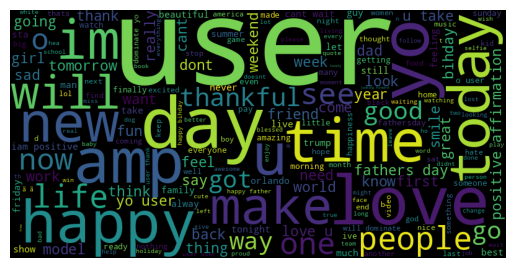

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['tweet'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis('off')
plt.show()

### Splitting the data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df['tweet']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


### Tokenization & Vocabulary

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

vocab_size = 5000
max_len = 25

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

### Text to Sequence

In [ ]:
X_seq = tokenizer.texts_to_sequences(X_train)

Xt_seq = tokenizer.texts_to_sequences(X_test)

### Padding

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_pad = pad_sequences(X_seq, maxlen=max_len, padding='post',truncating='post')

Xt_pad = pad_sequences(Xt_seq, maxlen=max_len, padding='post',truncating='post')

### MODEL BUILDING with RNN

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

# Input layer
input_layer = Input(shape=(max_len,))

# Embedding
embedding = Embedding(input_dim=vocab_size, output_dim=16)(input_layer)

# RNN
rnn = SimpleRNN(32)(embedding)

# Output
output = Dense(1, activation='sigmoid')(rnn)

# Model
model = Model(inputs=input_layer, outputs=output)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 25, 16)         │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,601 (318.75 KB)

 Trainable params: 81,601 (318.75 KB)

 Non-trainable params: 0 (0.00 B)

### COMPILE MODEL

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

### Training

In [ ]:
history = model.fit(
    X_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9277 - loss: 0.2613 - val_accuracy: 0.9292 - val_loss: 0.2557
Epoch 2/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9305 - loss: 0.2485 - val_accuracy: 0.9308 - val_loss: 0.2441
Epoch 3/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9324 - loss: 0.2248 - val_accuracy: 0.9308 - val_loss: 0.2361
Epoch 4/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9300 - loss: 0.2162 - val_accuracy: 0.9214 - val_loss: 0.2586
Epoch 5/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9438 - loss: 0.1860 - val_accuracy: 0.9261 - val_loss: 0.2456
Epoch 6/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9520 - loss: 0.1597 - val_accuracy: 0.9171 - val_loss: 0.2643
Epoch 7/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9592 - loss: 0.1425 - val_accuracy: 0.9187 - val_loss: 0.2769
Epoch 8/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9653 - loss: 0.1249 - val_accuracy: 0.

## Predictions

In [ ]:
y_pred_prob = model.predict(Xt_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


### Accuracy

In [ ]:
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

Test Accuracy: 0.8977006100422337


In [ ]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.28602620087336245


### Model Building using GRU

In [ ]:
from tensorflow.keras.layers import GRU, Input, Embedding, Dense
from tensorflow.keras.models import Model

# Input
input_layer = Input(shape=(max_len,))

# Embedding
embedding = Embedding(input_dim=vocab_size, output_dim=16)(input_layer)

# GRU Layer
gru = GRU(32)(embedding)

# Output
output = Dense(1, activation='sigmoid')(gru)

# Model
model = Model(inputs=input_layer, outputs=output)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 25, 16)         │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,833 (331.38 KB)

 Trainable params: 84,833 (331.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.9275 - loss: 0.2653 - val_accuracy: 0.9292 - val_loss: 0.2539
Epoch 2/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9458 - loss: 0.1674 - val_accuracy: 0.9417 - val_loss: 0.1623
Epoch 3/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9623 - loss: 0.1119 - val_accuracy: 0.9468 - val_loss: 0.1609
Epoch 4/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9699 - loss: 0.0925 - val_accuracy: 0.9441 - val_loss: 0.1731
Epoch 5/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9740 - loss: 0.0805 - val_accuracy: 0.9445 - val_loss: 0.1712
Epoch 6/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9778 - loss: 0.0698 - val_accuracy: 0.9449 - val_loss: 0.1824
Epoch 7/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9809 - loss: 0.0619 - val_accuracy: 0.9441 - val_loss: 0.2032
Epoch 8/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9838 - loss: 0.0533 - val_accuracy: 

In [ ]:
y_pred_prob = model.predict(Xt_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

Test Accuracy: 0.9449397778820585


In [ ]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.5707317073170731
